In [32]:
from langgraph.graph import StateGraph
from typing import List , TypedDict
import math


In [33]:
class AgentState(TypedDict):
    name : str
    value : List[int]
    total : str

In [34]:
def process_values(state : AgentState) -> AgentState:
    state["total"] = "Hi my name is {state['name']} the sum of the values are {sum(state['value'])}"    
    return state

In [35]:
graph =StateGraph(AgentState)
graph.add_node("processing" , process_values)
graph.set_entry_point("processing")
graph.set_finish_point("processing")


app = graph.compile()

result = app.invoke({
    "name" : "charan",
    "value":[1,2,3,4,5,4,],
})
print(result)


{'name': 'charan', 'value': [1, 2, 3, 4, 5, 4], 'total': "Hi my name is {state['name']} the sum of the values are {sum(state['value'])}"}


#### 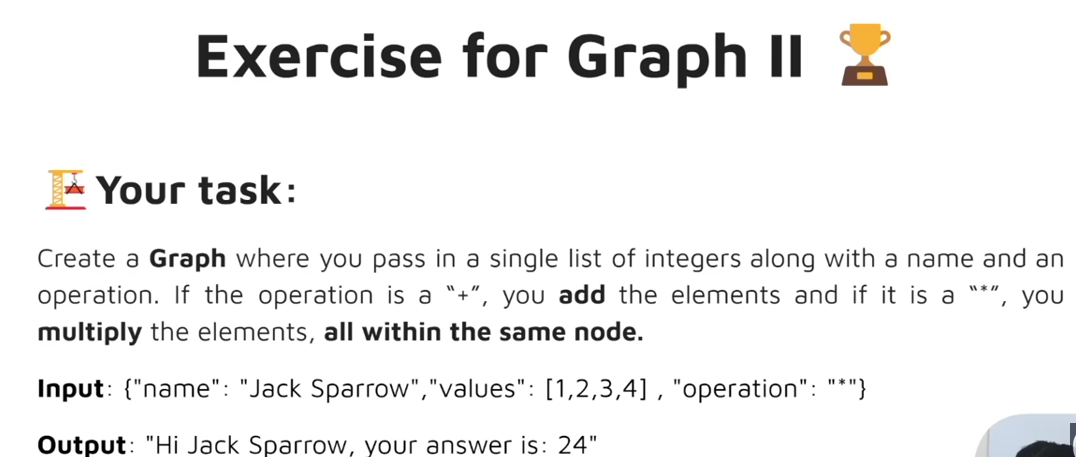

In [38]:
class AgentState1( TypedDict):
    name : str
    values : List[int]
    operation : str
    result : str 

def Operations_performer(state : AgentState1):

    if state["operation"] == "*":
        state["result"]  = f" hi my name is{state["name"]} and the values to be multiplied are{state["values"]}and the product of the values is { math.prod(state["values"])}"
    else:
        state["result"]  = f" hi my name is{state["name"]} and the values to be sumed are{state["values"]}and the sum is {sum(state["values"])}"

    return state 

In [39]:
graph = StateGraph(AgentState1)

graph.add_node("operation",Operations_performer)

graph.set_entry_point("operation")
graph.set_finish_point("operation")


app  = graph.compile()


app.invoke({
    "name" : "charan",
    "values" : [1,3,4,55,5,5],
    "operation" : "*"
})


{'name': 'charan',
 'values': [1, 3, 4, 55, 5, 5],
 'operation': '*',
 'result': ' hi my name ischaran and the values to be multiplied are[1, 3, 4, 55, 5, 5]and the product of the values is 16500'}